In [1]:
import pandas as pd
import yfinance as yf
import matplotlib.pyplot as plt

In [2]:
delia_ticker = "DELIA.OL"

### Financial statement analysis

In [3]:
income = yf.Ticker(delia_ticker).financials

income.head()

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Tax Effect Of Unusual Items,0.000000e+00,0.000000e+00,0.000000e+00,0.00
Tax Rate For Calcs,2.325100e-01,2.442200e-01,3.186410e-01,0.22
Normalized EBITDA,6.977000e+07,1.196200e+07,4.774000e+06,1024000.00
Net Income From Continuing Operation Net Minority Interest,4.918900e+07,2.806000e+06,3.567000e+06,410000.00
Reconciled Depreciation,2.611000e+06,1.431000e+06,9.050000e+05,393000.00


Key ratios we want to find: 
- Gross profit margin
- Ebit / Revenue
- Ebitda / Revenue

In [4]:
income_ratios = {
    'Gross profit margin, %': (income.loc['Gross Profit'] / income.loc['Total Revenue'] * 100).round(2),
    'Ebitda / Revenue, %': (income.loc['EBITDA'] / income.loc['Total Revenue'] * 100).round(2),
    'Ebit / Revenue, %': (income.loc['EBIT'] / income.loc['Total Revenue'] * 100).round(2),
}

income_ratios

{'Gross profit margin, %': 2025-12-31    32.97
 2024-12-31    32.91
 2023-12-31    36.52
 2022-12-31    24.26
 dtype: float64,
 'Ebitda / Revenue, %': 2025-12-31    10.93
 2024-12-31     4.50
 2023-12-31     4.51
 2022-12-31     1.93
 dtype: float64,
 'Ebit / Revenue, %': 2025-12-31    10.52
 2024-12-31     3.96
 2023-12-31     3.65
 2022-12-31     1.19
 dtype: float64}

In [5]:
income_df = pd.DataFrame(income_ratios)
income_df

,"Gross profit margin, %","Ebitda / Revenue, %","Ebit / Revenue, %"
2025-12-31,32.97,10.93,10.52
2024-12-31,32.91,4.50,3.96
2023-12-31,36.52,4.51,3.65
2022-12-31,24.26,1.93,1.19


### Balance sheet analysis

In [6]:
balance_sheet = yf.Ticker(delia_ticker).balance_sheet

print(balance_sheet.to_string())

                                                         2025-12-31   2024-12-31  2023-12-31  2022-12-31  2021-12-31
Treasury Shares Number                                      76895.0          NaN         NaN         NaN         NaN
Ordinary Shares Number                                    5383105.0    4733105.0   4733105.0   4733105.0         NaN
Share Issued                                              5460000.0    4733105.0   4733105.0   4733105.0         NaN
Net Debt                                                        NaN   15793000.0         NaN         NaN         NaN
Total Debt                                              117475000.0   25490000.0   1833000.0   1023000.0         NaN
Tangible Book Value                                     387153000.0   48603000.0  53308000.0  23876000.0         NaN
Invested Capital                                        493279000.0   71561000.0  54229000.0  24533000.0         NaN
Working Capital                                         38006300

In [ ]:
bs_ratios = pd.DataFrame({
    'Current ratio': balance_sheet.loc['Current Assets'] / balance_sheet.loc['Current Liabilities'],
    'Quick ratio': (balance_sheet.loc['Cash And Cash Equivalents'] + balance_sheet.loc['Accounts Receivable']) / balance_sheet.loc['Current Liabilities'],
    'Equity ratio': balance_sheet.loc['Stockholders Equity'] / balance_sheet.loc['Total Assets'],
    'Debt to Equity ratio': balance_sheet.loc['Total Liabilities Net Minority Interest'] / balance_sheet.loc['Stockholders Equity']
}
).round(3)

bs_ratios.index = bs_ratios.index.year  # display years only
bs_ratios = bs_ratios.sort_index(ascending=True)
print(bs_ratios)

      Current ratio  Quick ratio  Equity ratio  Debt to Equity ratio
2021            NaN          NaN           NaN                   NaN
2022          6.348        4.110         0.874                 0.198
2023          4.345        2.587         0.799                 0.301
2024          1.689        0.594         0.421                 1.378
2025          2.896        1.693         0.648                 0.543


In [ ]:
metrics = pd.DataFrame({
    "ROE (%)": (income.loc["Net Income"] / balance_sheet.loc["Stockholders Equity"] * 100).round(2),
    "Asset Turnover": (income.loc["Total Revenue"] / balance_sheet.loc["Total Assets"]).round(2)
})

metrics.index = metrics.index.year 
print(metrics)

      ROE (%)  Asset Turnover
2021      NaN             NaN
2022     1.72            1.94
2023     6.69            1.59
2024     5.77            2.30
2025    12.71            1.07


In [41]:
avg_roe_25 = round(income["2025-12-31"]["Net Income"] / (( balance_sheet["2025-12-31"]["Stockholders Equity"] + balance_sheet["2024-12-31"]["Stockholders Equity"] ) / 2), 4) * 100
print(f"Average ROE for 2025: {avg_roe_25:.2f}%")

Average ROE for 2025: 22.58%


In [45]:
# Hent total assets
total_assets = balance_sheet.loc["Total Assets"].sort_index()
revenue = income.loc["Total Revenue"].sort_index()

at = pd.DataFrame({
    "Revenue (MNOK)": revenue / 1e6,
    "Total Assets (MNOK)": total_assets / 1e6,
})

at["Avg Assets (MNOK)"] = at["Total Assets (MNOK)"].rolling(2).mean()
at["Asset Turnover - ending"] = (at["Revenue (MNOK)"] / at["Total Assets (MNOK)"]).round(2)
at["Asset Turnover - avg"] = (at["Revenue (MNOK)"] / at["Avg Assets (MNOK)"]).round(2)

at.index = at.index.year
print(at.round(2).to_string())

      Revenue (MNOK)  Total Assets (MNOK)  Avg Assets (MNOK)  Asset Turnover - ending  Asset Turnover - avg
2021             NaN                  NaN                NaN                      NaN                   NaN
2022           52.94                27.32                NaN                     1.94                   NaN
2023          105.90                66.72              47.02                     1.59                  2.25
2024          265.97               115.58              91.15                     2.30                  2.92
2025          638.29               597.37             356.48                     1.07                  1.79


In [46]:
cashflow = yf.Ticker(delia_ticker).cashflow
cashflow

,2025-12-31,2024-12-31,2023-12-31,2022-12-31
Free Cash Flow,-35873000.0,-35578000.0,-10958000.0,-3161000.0
Repayment Of Debt,-138000.0,-149000.0,0.0,0.0
Issuance Of Debt,12541000.0,22127000.0,0.0,0.0
Issuance Of Capital Stock,301598000.0,0.0,27869000.0,18404000.0
Capital Expenditure,-4645000.0,-613000.0,-570000.0,-465000.0
End Cash Position,263737000.0,7387000.0,30256000.0,15474000.0
Other Cash Adjustment Outside Changein Cash,1000.0,1000.0,1000.0,NaN
Beginning Cash Position,7387000.0,30256000.0,15474000.0,4010000.0
Effect Of Exchange Rate Changes,-243000.0,-58000.0,179000.0,52000.0
Changes In Cash,256592000.0,-22812000.0,14602000.0,11412000.0


In [49]:
# Hent operasjonell kontantstrøm
operating_cf = cashflow.loc["Operating Cash Flow"].sort_index()

ocf = pd.DataFrame({
    "Operating CF (MNOK)": operating_cf / 1e6
})

ocf.index = ocf.index.year
print(ocf.round(1).to_string())

      Operating CF (MNOK)
2022                 -2.7
2023                -10.4
2024                -35.0
2025                -31.2


In [50]:
net_income = income.loc["Net Income"].sort_index()

quality = pd.DataFrame({
    "Net Income (MNOK)": net_income / 1e6,
    "Operating CF (MNOK)": operating_cf / 1e6,
})

quality["Gap (MNOK)"] = quality["Operating CF (MNOK)"] - quality["Net Income (MNOK)"]
quality["OCF / Net Income"] = (quality["Operating CF (MNOK)"] / quality["Net Income (MNOK)"]).round(2)

quality.index = quality.index.year
print(quality.round(1).to_string())

      Net Income (MNOK)  Operating CF (MNOK)  Gap (MNOK)  OCF / Net Income
2022                0.4                 -2.7        -3.1              -6.6
2023                3.6                -10.4       -14.0              -2.9
2024                2.8                -35.0       -37.8             -12.5
2025               49.2                -31.2       -80.4              -0.6


In [51]:
# Sjekk endring i arbeidskapital
working_capital_change = cashflow.loc["Change In Working Capital"].sort_index()

wc = pd.DataFrame({
    "Change in Working Capital (MNOK)": working_capital_change / 1e6
})

wc.index = wc.index.year
print(wc.round(1).to_string())

      Change in Working Capital (MNOK)
2022                              -1.2
2023                             -13.5
2024                             -37.5
2025                             -95.9


Net income looks good - the company made 49M NOK in 2025. But the 
actual cash flow from operations was negative (-31M). That's weird, 
so I wanted to understand why.

Checked working capital changes and it's very negative too 
(-95M in 2025). This basically explains the gap. My guess is the 
company needs to buy/produce a lot of inventory and give stores 
credit before they get paid (accounts receivable), so even though 
they're "profitable" on paper, the cash isn't actually coming in yet.

This is pretty normal for a fast-growing company, but it also kind 
of explains why they needed the IPO money. The growth itself 
costs cash, and operations alone don't cover it.

In [52]:
capex = cashflow.loc["Capital Expenditure"].sort_index()

fcf = pd.DataFrame({
    "Operating CF (MNOK)": operating_cf / 1e6,
    "CapEx (MNOK)": capex / 1e6,
})

fcf["Free Cash Flow (MNOK)"] = fcf["Operating CF (MNOK)"] + fcf["CapEx (MNOK)"]

fcf.index = fcf.index.year
print(fcf.round(1).to_string())

      Operating CF (MNOK)  CapEx (MNOK)  Free Cash Flow (MNOK)
2022                 -2.7          -0.5                   -3.2
2023                -10.4          -0.6                  -11.0
2024                -35.0          -0.6                  -35.6
2025                -31.2          -4.6                  -35.9


In [54]:
capex = cashflow.loc["Capital Expenditure"].sort_index()

fcf = pd.DataFrame({
    "Operating CF (MNOK)": operating_cf / 1e6,
    "CapEx (MNOK)": capex / 1e6,
})

fcf["Free Cash Flow (MNOK)"] = fcf["Operating CF (MNOK)"] + fcf["CapEx (MNOK)"]

fcf.index = fcf.index.year
print(fcf.round(1).to_string())

      Operating CF (MNOK)  CapEx (MNOK)  Free Cash Flow (MNOK)
2022                 -2.7          -0.5                   -3.2
2023                -10.4          -0.6                  -11.0
2024                -35.0          -0.6                  -35.6
2025                -31.2          -4.6                  -35.9


### CapEx and Free Cash Flow

Turns out CapEx is small (they don't own factories - probably 
outsource production). So free cash flow basically just follows 
operating cash flow, which we already know is negative.

This makes the working capital story even more clear - growth 
itself is what's eating the cash, not investments in equipment 
or buildings. And it explains why they needed the IPO money: 
they burned around 85M NOK in free cash flow over the last two 
years alone.

### Cash Runway

In [56]:
# Hent siste kjente cash-posisjon
cash_position = balance_sheet.loc["Cash And Cash Equivalents"].sort_index()
latest_cash = cash_position.iloc[-1] / 1e6

# Gjennomsnittlig FCF-forbruk siste 2 år (siden veksten har stabilisert seg på ca samme nivå)
avg_fcf_burn = fcf["Free Cash Flow (MNOK)"].iloc[-2:].mean()

runway_years = latest_cash / abs(avg_fcf_burn)

print(f"Cash position (latest): {latest_cash:.1f} MNOK")
print(f"Average annual FCF burn (last 2 years): {avg_fcf_burn:.1f} MNOK")
print(f"Estimated cash runway: {runway_years:.1f} years")

Cash position (latest): 263.7 MNOK
Average annual FCF burn (last 2 years): -35.7 MNOK
Estimated cash runway: 7.4 years


In [58]:
financing_cf = cashflow.loc["Financing Cash Flow"].sort_index()

fin = pd.DataFrame({
    "Cash from Financing (MNOK)": financing_cf / 1e6
})

fin.index = fin.index.year
print(fin.round(1).to_string())

      Cash from Financing (MNOK)
2022                        14.6
2023                        24.6
2024                        11.5
2025                       291.8


### Cash Runway & Financing

Good news: even with negative cash flow, the company has about 
7.4 years of runway at current burn rate. So they're not in 
immediate danger.

The financing cash flow numbers also confirm the IPO story - 
they raised about 292M NOK in 2025, way more than any previous 
year (which were more like 11-25M, probably small loans or 
similar). This is clearly what gave them breathing room to 
keep growing despite burning cash on operations.

## Forward-Looking Valuation

### Where Delia stands today

Delia has grown revenue from 53M to 638M NOK in four years (2022-2025), 
with margins improving sharply along the way - operating margin went 
from 2.5% to 11.7%. ROE landed at 22.6% in 2025, which looks strong 
on paper.

But the cash flow side tells a more complicated story. Operating cash 
flow has been negative every single year, and the gap to net income 
widened a lot in 2025 (+49M net income vs -31M operating cash flow). 
This comes mostly from working capital - the company needs to fund 
inventory and receivables to keep growing.

The IPO solved the immediate problem - they raised 292M NOK in 2025, 
giving them roughly 7.4 years of runway at current burn rate. So 
short-term survival isn't a concern.

The real question going forward is: can growth slow down to a level 
where the business becomes cash flow positive, or does growth always 
require this much external funding?


### Revenue Forecast (2026–2030)

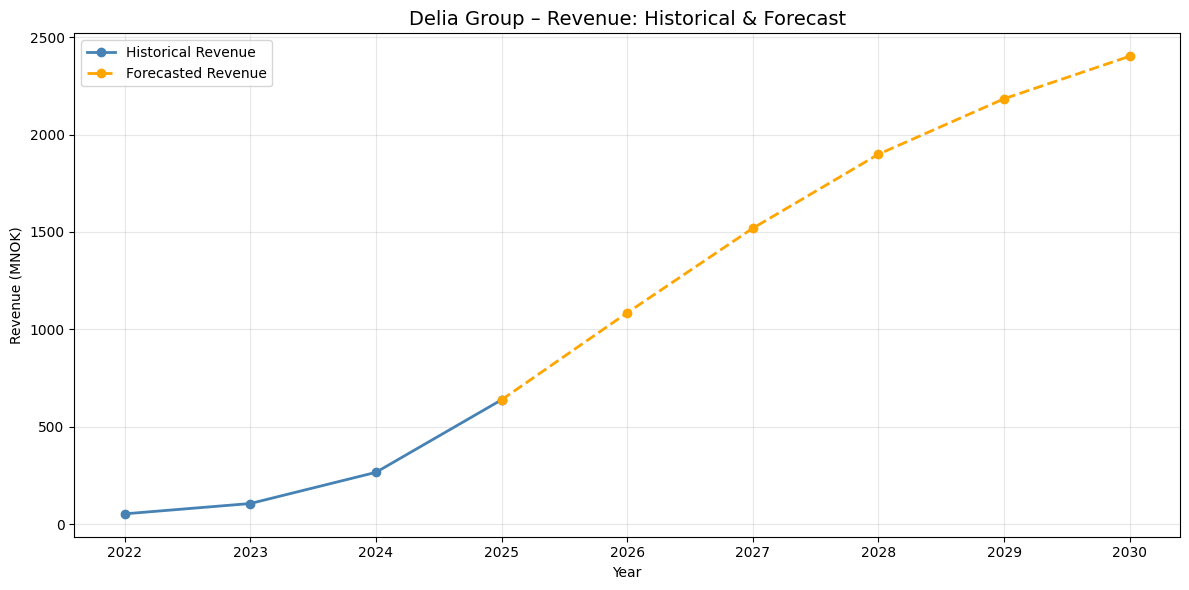

      Revenue (MNOK)        Type  YoY Growth %
2022            52.9  Historical           NaN
2023           105.9  Historical         100.0
2024           266.0  Historical         151.2
2025           638.3  Historical         140.0
2026          1085.1    Forecast          70.0
2027          1519.1    Forecast          40.0
2028          1898.9    Forecast          25.0
2029          2183.8    Forecast          15.0
2030          2402.1    Forecast          10.0


In [61]:
# Hent omsetning fra resultatregnskapet (riktig variabelnavn: income)
revenue = income.loc["Total Revenue"].sort_index()

rev_summary = pd.DataFrame({
    "Revenue (MNOK)": revenue / 1e6
})
rev_summary.index = rev_summary.index.year

# Forecast - avtagende vekstrate fremover
last_revenue = rev_summary["Revenue (MNOK)"].iloc[-1]
last_year = rev_summary.index[-1]

growth_assumptions = {
    last_year + 1: 0.70,
    last_year + 2: 0.40,
    last_year + 3: 0.25,
    last_year + 4: 0.15,
    last_year + 5: 0.10,
}

forecast = {}
rev = last_revenue
for year, growth in growth_assumptions.items():
    rev = rev * (1 + growth)
    forecast[year] = rev

forecast_df = pd.DataFrame.from_dict(forecast, orient="index", columns=["Revenue (MNOK)"])

# Kombiner historikk og forecast
historical = rev_summary["Revenue (MNOK)"]
forecasted = forecast_df["Revenue (MNOK)"]

all_years = list(historical.index) + list(forecasted.index)
all_values = list(historical.values) + list(forecasted.values)

# --- GRAF ---
plt.figure(figsize=(12, 6))

plt.plot(historical.index, historical.values,
          marker="o", color="steelblue", linewidth=2, label="Historical Revenue")

forecast_x = [historical.index[-1]] + list(forecasted.index)
forecast_y = [historical.values[-1]] + list(forecasted.values)
plt.plot(forecast_x, forecast_y,
          marker="o", color="orange", linewidth=2, linestyle="--", label="Forecasted Revenue")

plt.title("Delia Group – Revenue: Historical & Forecast", fontsize=14)
plt.ylabel("Revenue (MNOK)")
plt.xlabel("Year")
plt.xticks(all_years)
plt.legend()
plt.grid(alpha=0.3)
plt.tight_layout()
plt.show()

# --- TABELL ---
combined = pd.DataFrame({
    "Revenue (MNOK)": all_values,
    "Type": ["Historical"] * len(historical) + ["Forecast"] * len(forecasted)
}, index=all_years)

combined["YoY Growth %"] = combined["Revenue (MNOK)"].pct_change() * 100

print(combined.round(1).to_string())

### NTM Revenue & EV/Sales Valuation

In [62]:
# NTM = vektet snitt av inneværende og neste forecast-år
# Vi er ca. midtveis i 2026, så vekter 50/50 mellom 2026E og 2027E
rev_2026e = forecast_df.loc[2026, "Revenue (MNOK)"]
rev_2027e = forecast_df.loc[2027, "Revenue (MNOK)"]

ntm_revenue = 0.5 * rev_2026e + 0.5 * rev_2027e

print(f"2026E Revenue: {rev_2026e:.1f} MNOK")
print(f"2027E Revenue: {rev_2027e:.1f} MNOK")
print(f"NTM Revenue (blended): {ntm_revenue:.1f} MNOK")

2026E Revenue: 1085.1 MNOK
2027E Revenue: 1519.1 MNOK
NTM Revenue (blended): 1302.1 MNOK


In [64]:
ticker = yf.Ticker(delia_ticker)

shares_outstanding = ticker.info.get("sharesOutstanding")
current_price = ticker.info.get("currentPrice")

print(f"Shares outstanding: {shares_outstanding:,}")
print(f"Current price: {current_price} NOK")

total_debt_latest = balance_sheet.loc["Total Debt"].sort_index().iloc[-1]
cash_latest = balance_sheet.loc["Cash And Cash Equivalents"].sort_index().iloc[-1]
net_debt = (total_debt_latest - cash_latest) / 1e6

print(f"Net debt (negative = net cash): {net_debt:.1f} MNOK")

Shares outstanding: 43,064,840
Current price: 23.255 NOK
Net debt (negative = net cash): -146.2 MNOK


In [65]:
# EV/Sales multipler i tre scenarioer
scenarios = {
    "Low": 1.0,
    "Base": 2.0,
    "High": 3.5,
}

results = []
for scenario, multiple in scenarios.items():
    ev = ntm_revenue * multiple
    equity_value = ev - net_debt  # net_debt er negativ -> legger faktisk til cash
    price_target = (equity_value * 1e6) / shares_outstanding
    upside = (price_target / current_price - 1) * 100
    
    results.append({
        "Scenario": scenario,
        "EV/Sales": multiple,
        "Enterprise Value (MNOK)": round(ev, 1),
        "Equity Value (MNOK)": round(equity_value, 1),
        "Price Target (NOK)": round(price_target, 2),
        "Upside/Downside (%)": round(upside, 1),
    })

valuation = pd.DataFrame(results).set_index("Scenario")
print(valuation.to_string())

          EV/Sales  Enterprise Value (MNOK)  Equity Value (MNOK)  Price Target (NOK)  Upside/Downside (%)
Scenario                                                                                                 
Low            1.0                   1302.1               1448.3               33.63                 44.6
Base           2.0                   2604.2               2750.4               63.87                174.6
High           3.5                   4557.4               4703.6              109.22                369.7


In [66]:
# Dagens implisitte verdsettelse
current_market_cap = current_price * shares_outstanding / 1e6  # MNOK
current_ev = current_market_cap + net_debt

print(f"Current Market Cap: {current_market_cap:.1f} MNOK")
print(f"Current Enterprise Value: {current_ev:.1f} MNOK")

# Hvilken EV/Sales priser markedet inn akkurat nå (basert på 2025 faktisk omsetning)
actual_2025_revenue = rev_summary.loc[2025, "Revenue (MNOK)"]
implied_multiple_2025 = current_ev / actual_2025_revenue

print(f"\nImplied EV/Sales (vs 2025 actual revenue): {implied_multiple_2025:.2f}x")

# Hvilken EV/Sales priser markedet inn vs vår NTM-forecast
implied_multiple_ntm = current_ev / ntm_revenue

print(f"Implied EV/Sales (vs our NTM forecast): {implied_multiple_ntm:.2f}x")

# Snu spørsmålet: hvilken omsetning ville gitt dagens kurs ved en "normal" vekstmultippel (f.eks 1.5x)?
reasonable_multiple = 1.5
implied_revenue_needed = current_ev / reasonable_multiple

print(f"\nIf market uses {reasonable_multiple}x multiple,")
print(f"implied revenue would need to be: {implied_revenue_needed:.1f} MNOK")
print(f"(vs our NTM forecast of {ntm_revenue:.1f} MNOK)")

Current Market Cap: 1001.5 MNOK
Current Enterprise Value: 855.3 MNOK

Implied EV/Sales (vs 2025 actual revenue): 1.34x
Implied EV/Sales (vs our NTM forecast): 0.66x

If market uses 1.5x multiple,
implied revenue would need to be: 570.2 MNOK
(vs our NTM forecast of 1302.1 MNOK)


### So is the market irrational, or are we?

Turns out the market isn't pricing Delia irrationally low - 
relative to actual 2025 revenue, the implied multiple (1.34x) 
looks pretty normal. The disconnect is in growth expectations.

For today's price to make sense at a reasonable multiple (1.5x), 
revenue would need to land around 570M NOK - less than half of 
our 1302M NTM forecast. That means the market is betting on 
much slower growth than our model assumes.

Given the cash flow issues we found earlier (negative OCF, 
heavy working capital needs), this actually makes sense. 
Investors might be discounting the growth story because they're 
not convinced it's sustainable without constantly raising more 
capital. Our "upside" in the earlier scenarios was really just 
us assuming the market is wrong about growth - which it might 
be, but it's a real bet, not a fact.